In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

conf = (SparkConf()
            .setMaster("yarn")
            .set("spark.executor.cores", 5)
            .set("spark.sql.shuffle.partitions", 200)
            .set("spark.default.parallelism", 200)
            .set("spark.executor.memory", "7g")
            .set("spark.dynamicAllocation.maxExecutors", 20)
        )

spark = SparkSession \
    .builder \
    .config(conf=conf) \
    .appName("Graphs") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [2]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gold_path = "hdfs:///datos/gittba26/gittba03/oro"

df_gold = spark.read.parquet(gold_path)

In [3]:
silver_path = "hdfs:///datos/gittba26/gittba03/plata"
df_silver = spark.read.parquet(silver_path)



In [4]:
df_year = (
    df_silver
    .filter(F.col("year") == 2023)
    .orderBy("event_time")
    .select("event_time","open","high","low","close","volume")
)

pdf = df_year.toPandas()
pdf["event_time"] = pd.to_datetime(pdf["event_time"])

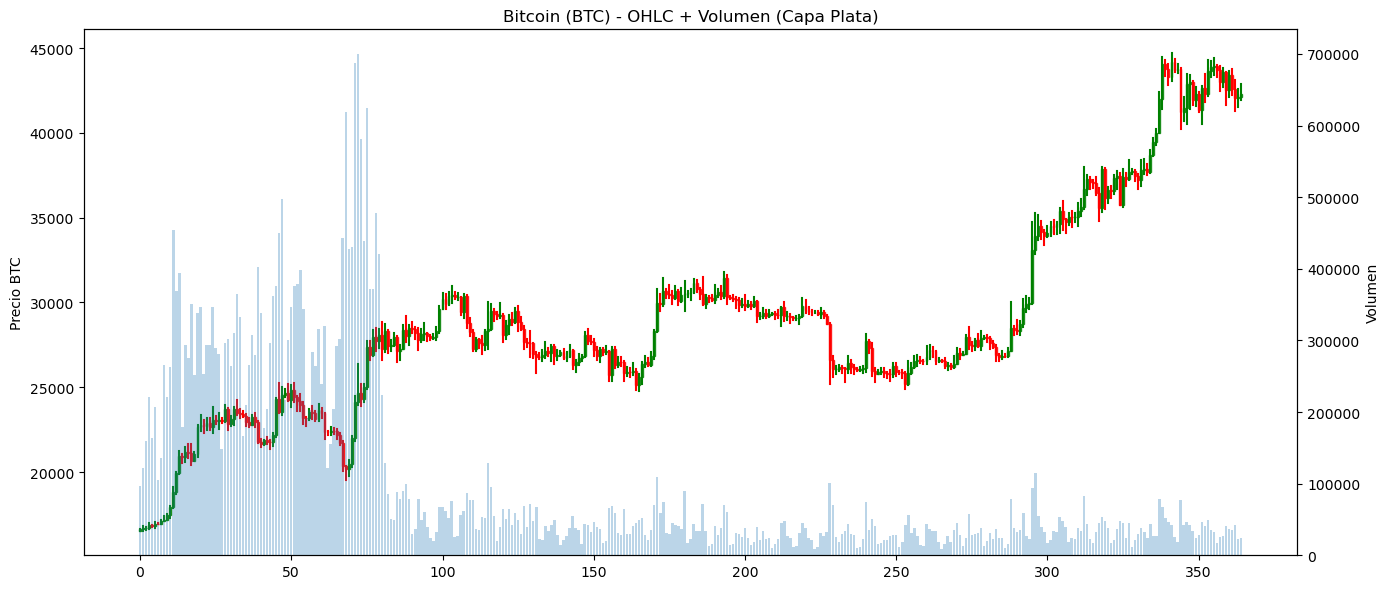

In [5]:
from matplotlib.patches import Rectangle

fig, ax1 = plt.subplots(figsize=(14,6))
width = 0.6

for i in range(len(pdf)):
    
    color = "green" if pdf["close"].iloc[i] >= pdf["open"].iloc[i] else "red"

    # Cuerpo
    ax1.add_patch(Rectangle(
        (i - width/2, min(pdf["open"].iloc[i], pdf["close"].iloc[i])),
        width,
        abs(pdf["close"].iloc[i] - pdf["open"].iloc[i]),
        color=color,
        alpha=0.8
    ))

    # Mecha
    ax1.plot([i, i],
             [pdf["low"].iloc[i], pdf["high"].iloc[i]],
             color=color)

ax1.set_ylabel("Precio BTC")

# Volumen
ax2 = ax1.twinx()
ax2.bar(range(len(pdf)), pdf["volume"], alpha=0.3)
ax2.set_ylabel("Volumen")

plt.title("Bitcoin (BTC) - OHLC + Volumen (Capa Plata)")
plt.tight_layout()
plt.show()

In [6]:
years = [row["year"] for row in df_gold.select("year").distinct().collect()]

for y in sorted(years):

    print(f"\n========== BITCOIN - AÑO {y} ==========")

    df_year = (
        df_gold
        .filter(F.col("year") == y)
        .orderBy("event_time")
        .select(
            "event_time",
            "open","high","low","close","volume",
            "sma_200","ema_50",
            "rsi_14",
            "macd","macd_signal"
        )
    )

    pdf = df_year.toPandas()
    pdf["event_time"] = pd.to_datetime(pdf["event_time"])


========== BITCOIN - AÑO 2022 ==========

========== BITCOIN - AÑO 2023 ==========

========== BITCOIN - AÑO 2024 ==========

========== BITCOIN - AÑO 2025 ==========


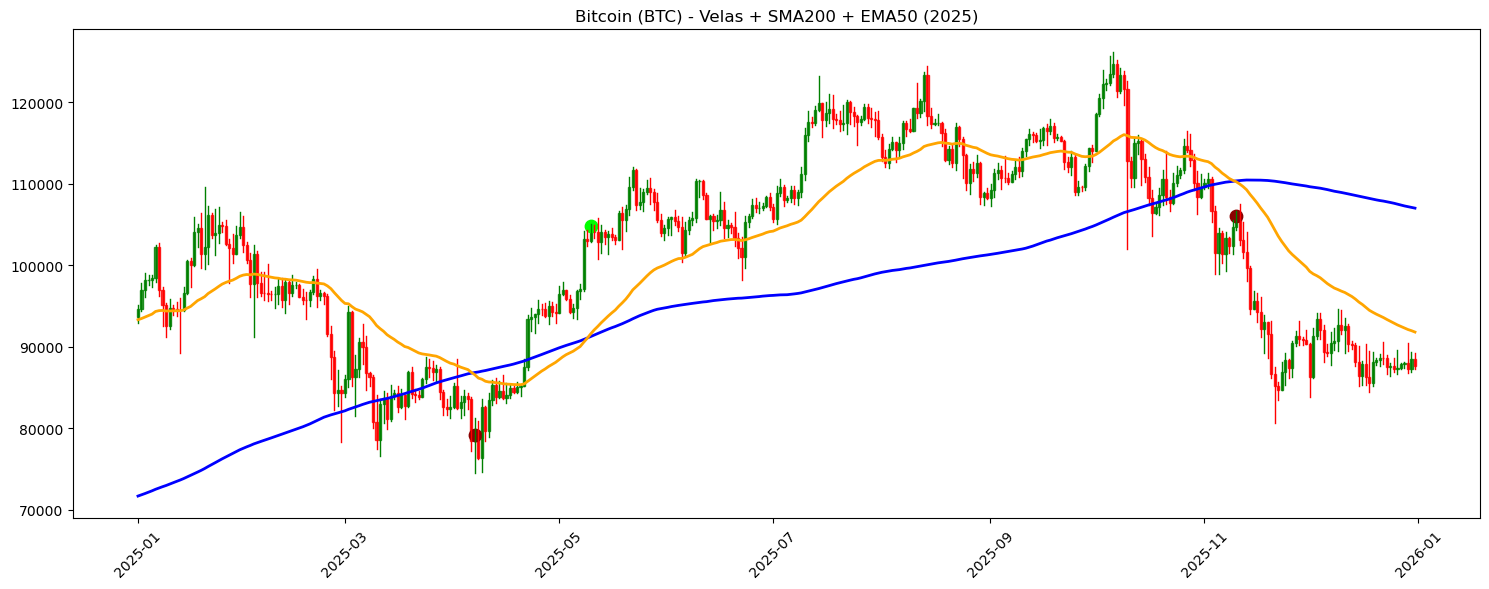

In [11]:
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,6))

# Convertir fechas a formato numérico matplotlib
pdf["date_num"] = mdates.date2num(pdf["event_time"])

width = 0.6  # ancho en días (ajusta si es intradiario)

for i in range(len(pdf)):

    if pdf["close"].iloc[i] >= pdf["open"].iloc[i]:
        color = "green"
    else:
        color = "red"

    # CUERPO
    ax.add_patch(Rectangle(
        (pdf["date_num"].iloc[i] - width/2,
         min(pdf["open"].iloc[i], pdf["close"].iloc[i])),
        width,
        abs(pdf["close"].iloc[i] - pdf["open"].iloc[i]),
        color=color,
        alpha=0.8
    ))

    # MECHA
    ax.plot([pdf["date_num"].iloc[i], pdf["date_num"].iloc[i]],
            [pdf["low"].iloc[i], pdf["high"].iloc[i]],
            color=color,
            linewidth=1)

# =====================
# Medias móviles
# =====================
ax.plot(pdf["date_num"], pdf["sma_200"], color="blue", linewidth=2)
ax.plot(pdf["date_num"], pdf["ema_50"], color="orange", linewidth=2)

# =====================
# Cruces
# =====================
cross_up = (
    (pdf["ema_50"] > pdf["sma_200"]) &
    (pdf["ema_50"].shift(1) <= pdf["sma_200"].shift(1))
)

cross_down = (
    (pdf["ema_50"] < pdf["sma_200"]) &
    (pdf["ema_50"].shift(1) >= pdf["sma_200"].shift(1))
)

ax.scatter(pdf["date_num"][cross_up],
           pdf["close"][cross_up],
           color="lime",
           s=80)

ax.scatter(pdf["date_num"][cross_down],
           pdf["close"][cross_down],
           color="darkred",
           s=80)

# Formatear eje X como fechas
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.title(f"Bitcoin (BTC) - Velas + SMA200 + EMA50 ({y})")
plt.tight_layout()
plt.show()

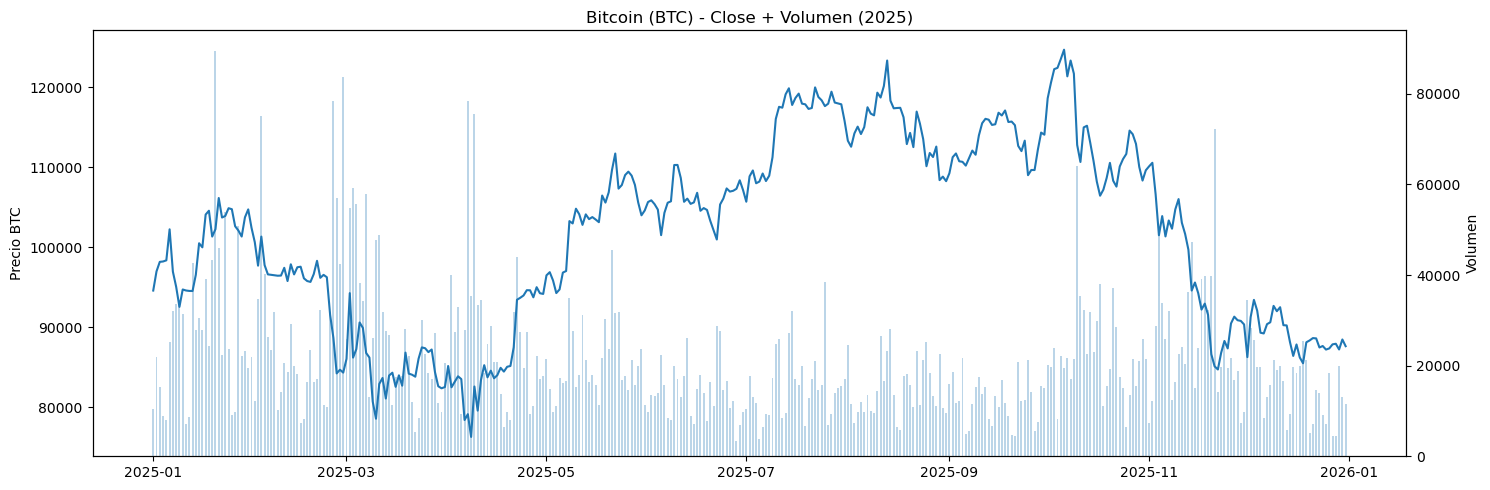

In [12]:
fig, ax1 = plt.subplots(figsize=(15,5))

# Convertir fechas a formato matplotlib
pdf["date_num"] = mdates.date2num(pdf["event_time"])

# Línea precio
ax1.plot(pdf["date_num"], pdf["close"], linewidth=1.5)
ax1.set_ylabel("Precio BTC")

# Volumen en eje secundario
ax2 = ax1.twinx()
ax2.bar(pdf["date_num"], pdf["volume"], width=0.6, alpha=0.3)
ax2.set_ylabel("Volumen")

# Formato eje X
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.title(f"Bitcoin (BTC) - Close + Volumen ({y})")
plt.tight_layout()
plt.show()

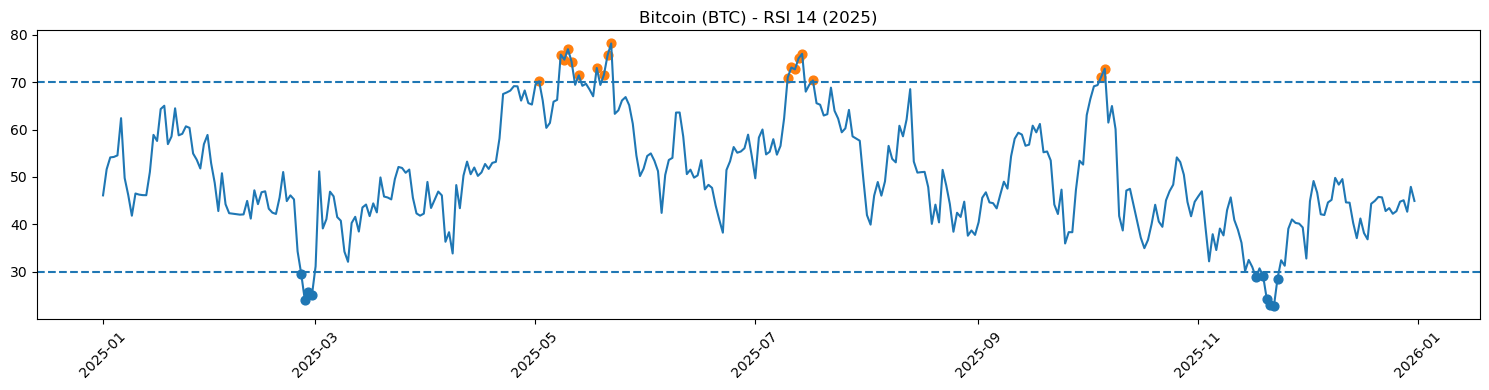

In [13]:
plt.figure(figsize=(15,4))

# Convertir fechas
pdf["date_num"] = mdates.date2num(pdf["event_time"])

# Línea RSI
plt.plot(pdf["date_num"], pdf["rsi_14"], linewidth=1.5)

# Líneas horizontales
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

# Puntos extremos
oversold = pdf["rsi_14"] < 30
overbought = pdf["rsi_14"] > 70

plt.scatter(pdf["date_num"][oversold],
            pdf["rsi_14"][oversold],
            s=40)

plt.scatter(pdf["date_num"][overbought],
            pdf["rsi_14"][overbought],
            s=40)

# Formato eje X
ax = plt.gca()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.title(f"Bitcoin (BTC) - RSI 14 ({y})")
plt.tight_layout()
plt.show()    

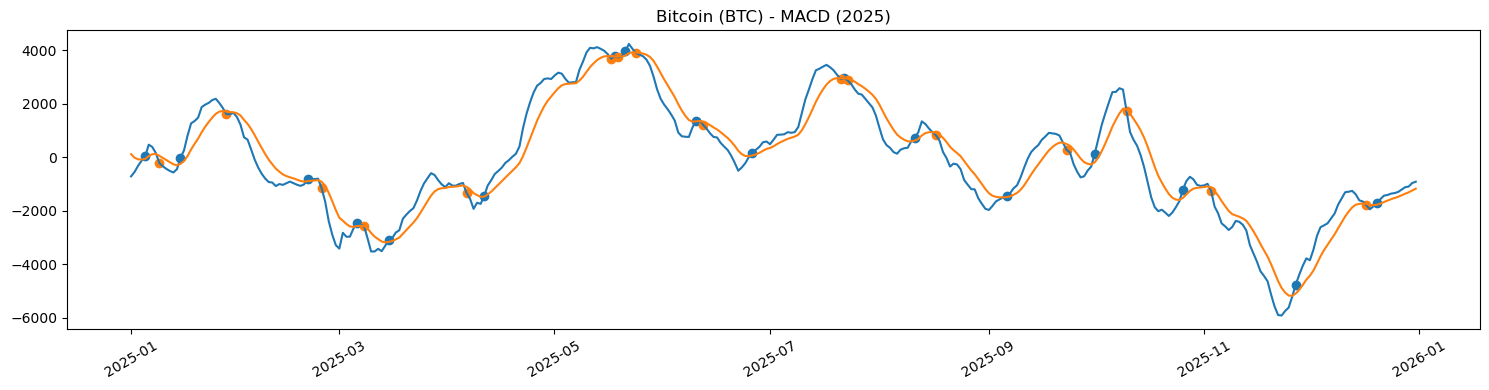

In [10]:
    macd_cross_up = (
        (pdf["macd"] > pdf["macd_signal"]) &
        (pdf["macd"].shift(1) <= pdf["macd_signal"].shift(1))
    )

    macd_cross_down = (
        (pdf["macd"] < pdf["macd_signal"]) &
        (pdf["macd"].shift(1) >= pdf["macd_signal"].shift(1))
    )

    plt.figure(figsize=(15,4))

    plt.plot(pdf["event_time"], pdf["macd"])
    plt.plot(pdf["event_time"], pdf["macd_signal"])

    plt.scatter(pdf["event_time"][macd_cross_up], pdf["macd"][macd_cross_up])
    plt.scatter(pdf["event_time"][macd_cross_down], pdf["macd"][macd_cross_down])

    plt.title(f"Bitcoin (BTC) - MACD ({y})")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()